In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print('✅ Libraries imported!')

✅ Libraries imported!


In [2]:
df = pd.read_csv('../data/tamil_nadu_waterborne_disease_data.csv')
print(f'✅ Data loaded: {df.shape[0]} rows')
df.head(3)

✅ Data loaded: 1008 rows


,date,year,month,month_name,district,rainfall_mm,temperature_celsius,pH,turbidity_NTU,coliform_count_per100ml,dissolved_oxygen_mg_L,total_dissolved_solids_mg_L,population,cholera_cases,diarrhea_cases,typhoid_cases,hepatitis_a_cases,total_disease_cases,outbreak_alert
0,2018-01-01,2018,1,January,Chennai,36.22,37.31,7.88,15.37,78.01,4.78,258.08,4544887,42,170,26,15,253,1
1,2018-02-01,2018,2,February,Chennai,13.95,34.11,8.36,1.02,496.11,7.09,811.65,1807371,62,243,44,20,369,1
2,2018-03-01,2018,3,March,Chennai,78.16,27.26,6.41,15.84,191.23,8.92,666.76,2928388,48,176,32,13,269,1


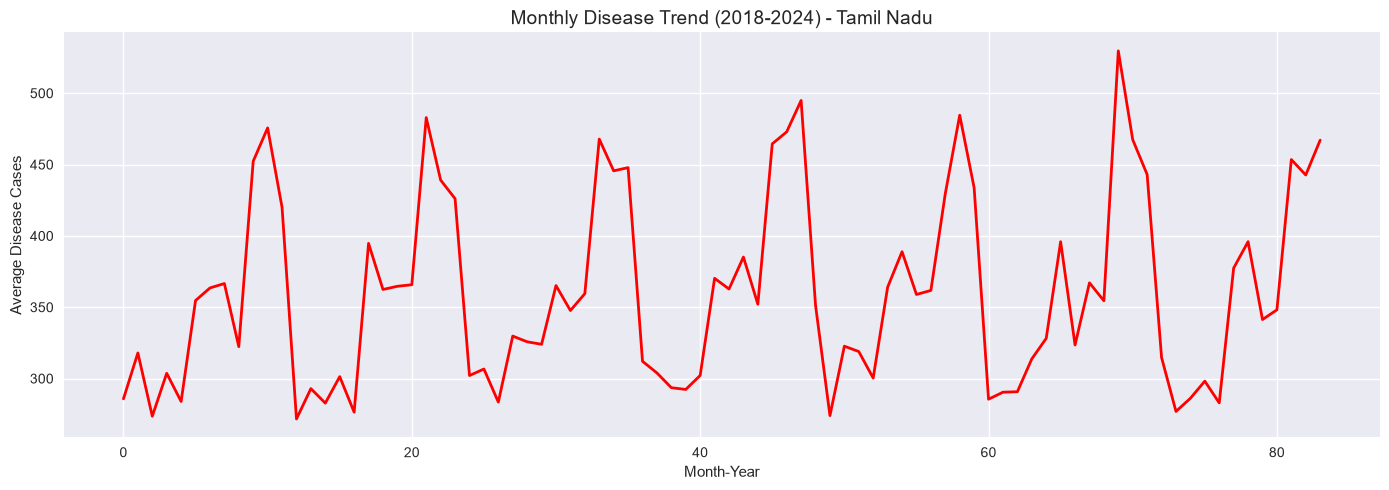

✅ Chart saved!


In [3]:
monthly_trend = df.groupby(['year', 'month'])['total_disease_cases'].mean().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(range(len(monthly_trend)), 
         monthly_trend['total_disease_cases'], 
         color='red', linewidth=2)
plt.title('Monthly Disease Trend (2018-2024) - Tamil Nadu', fontsize=14)
plt.xlabel('Month-Year')
plt.ylabel('Average Disease Cases')
plt.tight_layout()
plt.savefig('../reports/monthly_trend.png', dpi=150)
plt.show()
print('✅ Chart saved!')

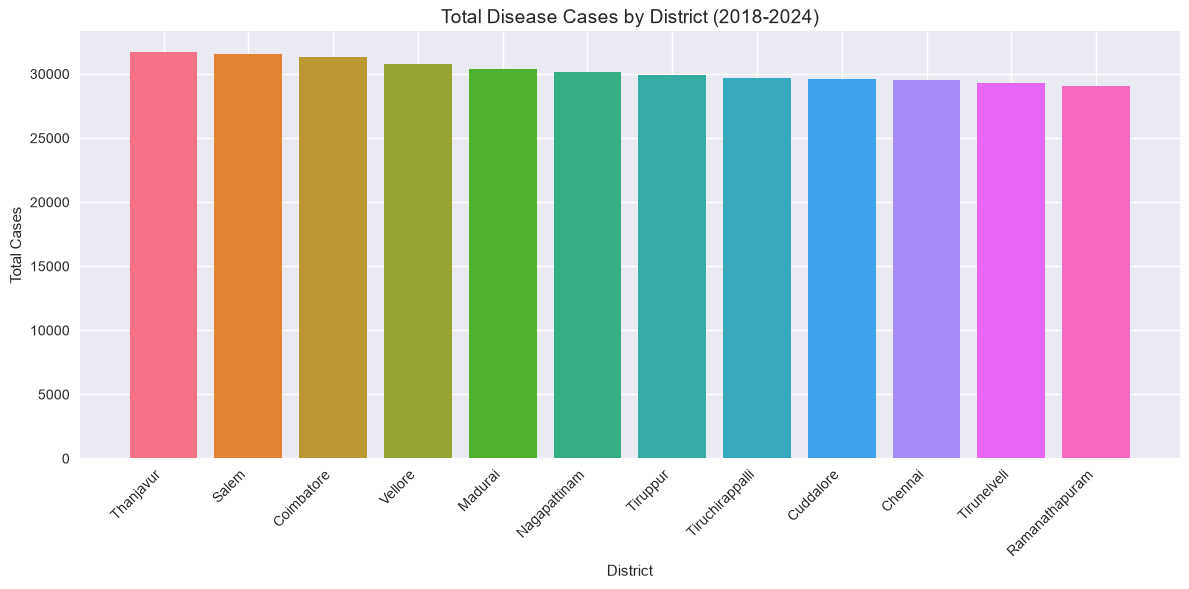

✅ Chart saved!


In [5]:
district_cases = df.groupby('district')['total_disease_cases'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(district_cases.index, district_cases.values, 
        color=sns.color_palette("husl", 12))
plt.title('Total Disease Cases by District (2018-2024)', fontsize=14)
plt.xlabel('District')
plt.ylabel('Total Cases')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/district_cases.png', dpi=150)
plt.show()
print('✅ Chart saved!')

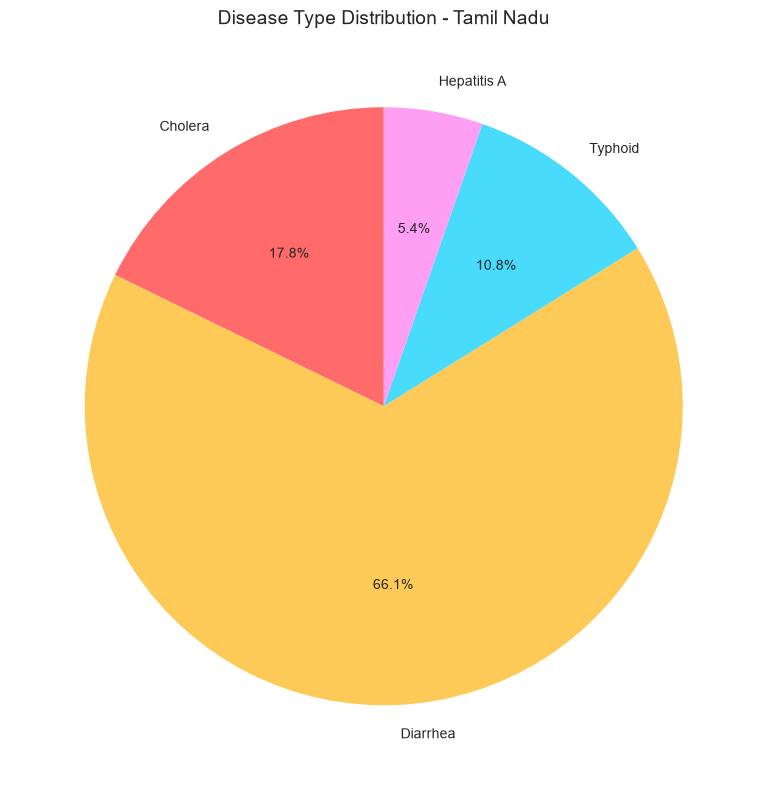

In [6]:
disease_totals = {
    'Cholera': df['cholera_cases'].sum(),
    'Diarrhea': df['diarrhea_cases'].sum(),
    'Typhoid': df['typhoid_cases'].sum(),
    'Hepatitis A': df['hepatitis_a_cases'].sum()
}

plt.figure(figsize=(8, 8))
colors = ['#ff6b6b', '#feca57', '#48dbfb', '#ff9ff3']
plt.pie(disease_totals.values(), labels=disease_totals.keys(),
        colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Disease Type Distribution - Tamil Nadu', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/disease_distribution.png', dpi=150)
plt.show()

In [7]:
print('='*50)
print('📊 KEY FINDINGS - EDA PART 1')
print('='*50)
print(f'\n🏥 Total Cases: {df["total_disease_cases"].sum():,}')
print(f'📅 Highest Risk Month: {df.groupby("month")["total_disease_cases"].mean().idxmax()}')
print(f'🗺️ Highest Risk District: {df.groupby("district")["total_disease_cases"].sum().idxmax()}')
print(f'⚠️ Total Outbreak Months: {df["outbreak_alert"].sum()}')
print('\n✅ EDA Part 1 Complete!')

📊 KEY FINDINGS - EDA PART 1

🏥 Total Cases: 363,074
📅 Highest Risk Month: 10
🗺️ Highest Risk District: Thanjavur
⚠️ Total Outbreak Months: 1008

✅ EDA Part 1 Complete!
